In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import datetime
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split

import keras
from keras.layers import Dense
from keras.models import Sequential
from keras.callbacks import EarlyStopping
import tensorflow.keras.utils
from keras.layers import LSTM

import statsmodels.tsa.api as smt
import statsmodels.api as sm
from statsmodels.tools.eval_measures import rmse

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'D:\Documents Learning\SCA\Final Project\synthetic_beverage_sales_data.csv')
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23


In [3]:
df = df.convert_dtypes()
df['Order_ID'] = df['Order_ID'].str[3:].astype('int')
df['Customer_ID'] = df['Customer_ID'].str[3:].astype('int')
df['Customer_Type'] = df['Customer_Type'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 11 columns):
 #   Column         Dtype         
---  ------         -----         
 0   Order_ID       int32         
 1   Customer_ID    int32         
 2   Customer_Type  category      
 3   Product        string        
 4   Category       category      
 5   Unit_Price     Float64       
 6   Quantity       Int64         
 7   Discount       Float64       
 8   Total_Price    Float64       
 9   Region         string        
 10  Order_Date     datetime64[ns]
dtypes: Float64(3), Int64(1), category(2), datetime64[ns](1), int32(2), string(2)
memory usage: 600.8 MB


In [4]:
df = df.rename(columns={'Order_Date': 'date', 'Total_Price': 'sales'})

In [5]:
def monthlyORyears_sales(data,time=['monthly','years']):
    data = data.copy()
    if time == "monthly":
        # Drop the day indicator from the date column:
        data.date = data.date.apply(lambda x: str(x)[:7])
    else:
        data.date = data.date.apply(lambda x: str(x)[:4])
        
   # Sum sales per month: 
    data = data.groupby('date')['sales'].sum().reset_index()
    data.date = pd.to_datetime(data.date)
        
    return data

In [6]:
m_df = monthlyORyears_sales(df, time='monthly')
m_df.head(10)

,date,sales
0,2021-01-01,32425429.08
1,2021-02-01,29110169.14
2,2021-03-01,32957436.5
3,2021-04-01,31142058.64
4,2021-05-01,31855490.12
5,2021-06-01,30993287.36
6,2021-07-01,32112059.34
7,2021-08-01,31925599.31
8,2021-09-01,31237668.17
9,2021-10-01,31867728.81


In [7]:
y_df = monthlyORyears_sales(df, time='years')
y_df.head(10)

,date,sales
0,2021-01-01,380046646.92
1,2022-01-01,394859780.08
2,2023-01-01,401774736.35


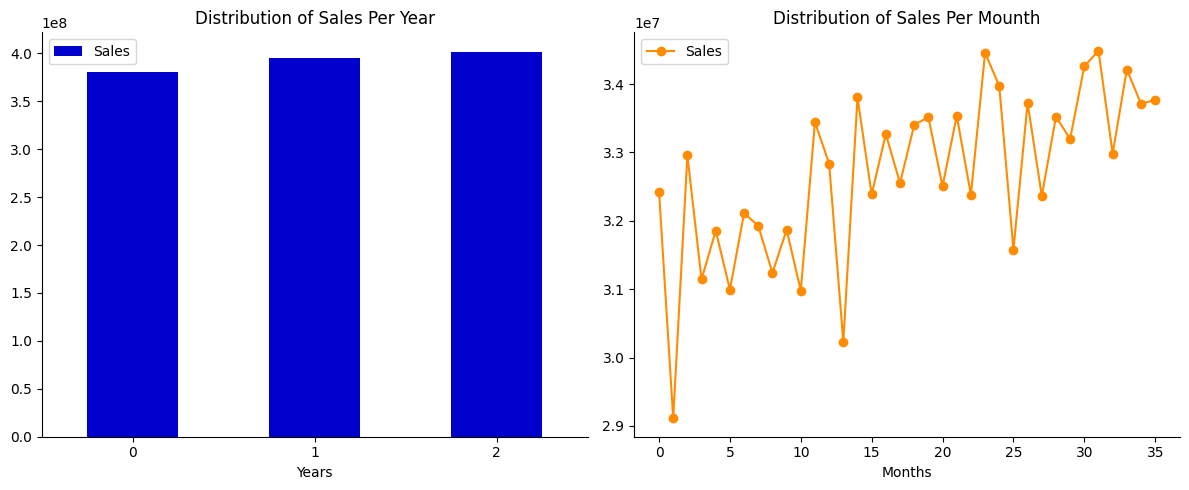

In [8]:
layout = (1, 2)

raw = plt.subplot2grid(layout, (0 ,0))
law = plt.subplot2grid(layout, (0 ,1))

years = y_df['sales'].plot(kind = "bar",color = 'mediumblue', label="Sales",ax=raw, figsize=(12,5))
months = m_df['sales'].plot(marker = 'o',color = 'darkorange', label="Sales", ax=law)

years.set(xlabel = "Years",title = "Distribution of Sales Per Year")
years.set_xticklabels(years.get_xticklabels(), rotation=0)
months.set(xlabel = "Months", title = "Distribution of Sales Per Mounth")

sns.despine()
plt.tight_layout()
years.legend()
months.legend()
plt.show();

In [9]:
def sales_time (data):
    data.date = pd.to_datetime(data.date)
    n_of_days = data.date.max() - data.date.min()
    n_of_years = int(n_of_days.days/365)
    print(f"Days: {n_of_days.days}\nYears: {n_of_years}\nMonth: {12 * n_of_years}")

In [10]:
sales_time(df)

Days: 1093
Years: 2
Month: 24


In [11]:
def time_plot(data, x_col, y_col, title):
    fig, ax = plt.subplots(figsize=(15, 8))
    sns.lineplot(x=x_col, y=y_col, data=data, ax=ax, color='darkblue', label='Total Sales')

    s_mean = data.groupby(data[x_col].dt.year)[y_col].mean().reset_index()
    s_mean['date'] = pd.to_datetime(s_mean[x_col].astype(str), format='%Y')
    sns.lineplot(x=(s_mean['date'] + pd.DateOffset(months=6)), y=y_col, data=s_mean, ax=ax, color='red', label='Mean Sales')

    ax.set(xlabel="Years",
           ylabel="Sales",
           title=title)
    ax.legend()
    plt.show()

In [12]:
m_df

,date,sales
0,2021-01-01,32425429.08
1,2021-02-01,29110169.14
2,2021-03-01,32957436.5
3,2021-04-01,31142058.64
4,2021-05-01,31855490.12
5,2021-06-01,30993287.36
6,2021-07-01,32112059.34
7,2021-08-01,31925599.31
8,2021-09-01,31237668.17
9,2021-10-01,31867728.81


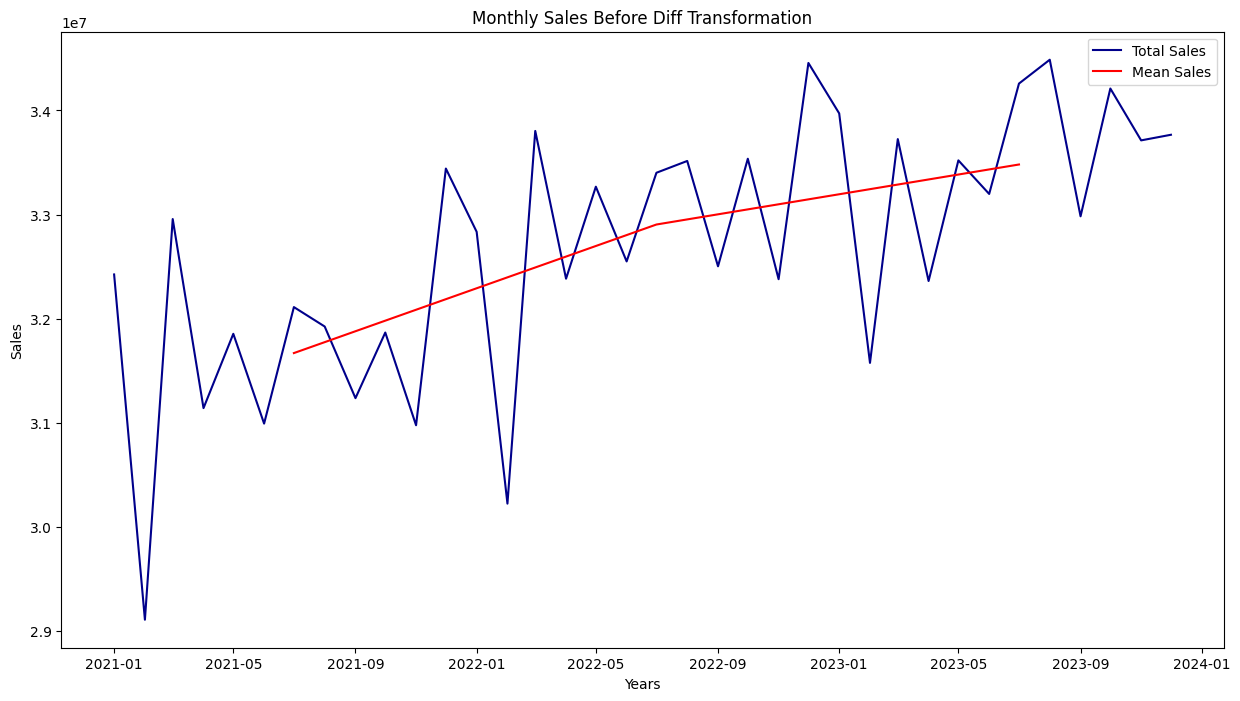

In [13]:
time_plot(m_df, 'date', 'sales', 'Monthly Sales Before Diff Transformation' )

In [14]:
def get_diff(data):
    """Calculate the difference in sales month over month:"""
    
    data['sales_diff'] = data.sales.diff()
    data = data.dropna()
    return data

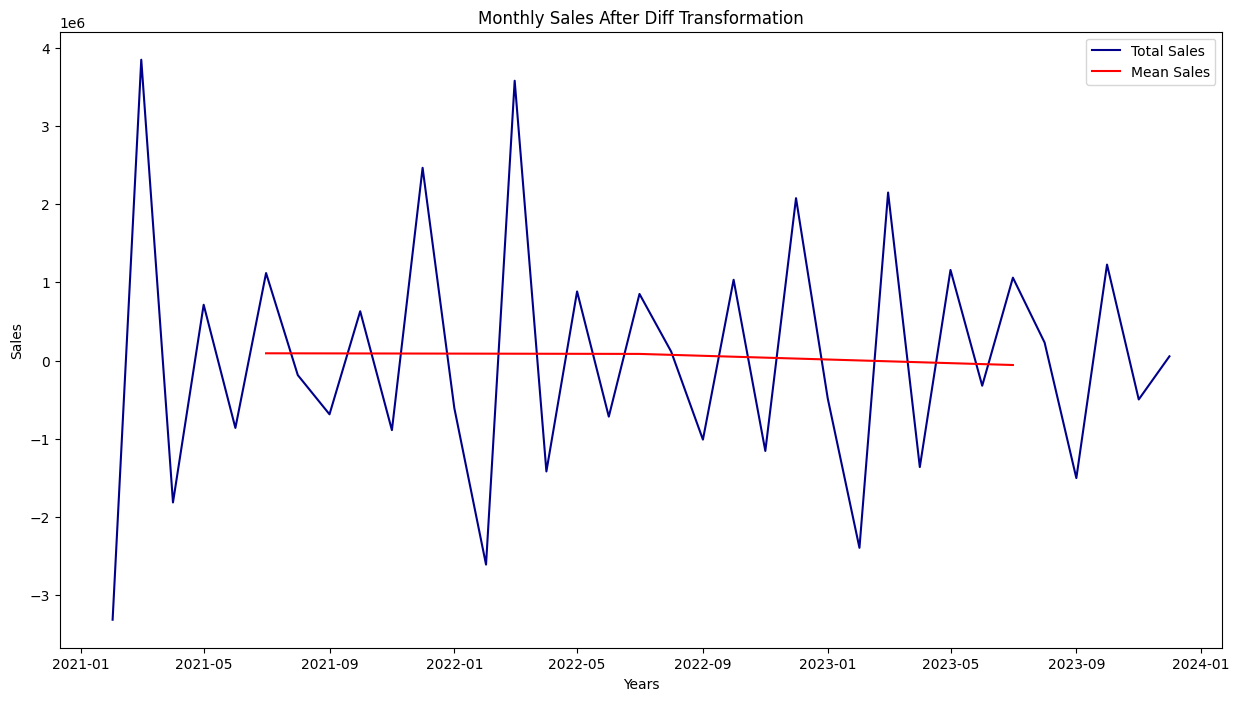

In [15]:
stationary_df = get_diff(m_df)
time_plot(stationary_df, 'date', 'sales_diff', 
          'Monthly Sales After Diff Transformation')

In [16]:
def build_arima_data(data):
    da_data = data.set_index('date').drop('sales', axis=1)
    da_data.dropna(axis=0)
    return da_data

In [17]:
datatime_df = build_arima_data(stationary_df)
datatime_df # ARIMA Dataframe

,sales_diff
date,
2021-02-01,-3315259.94
2021-03-01,3847267.36
2021-04-01,-1815377.86
2021-05-01,713431.48
2021-06-01,-862202.76
2021-07-01,1118771.98
2021-08-01,-186460.03
2021-09-01,-687931.14
2021-10-01,630060.64


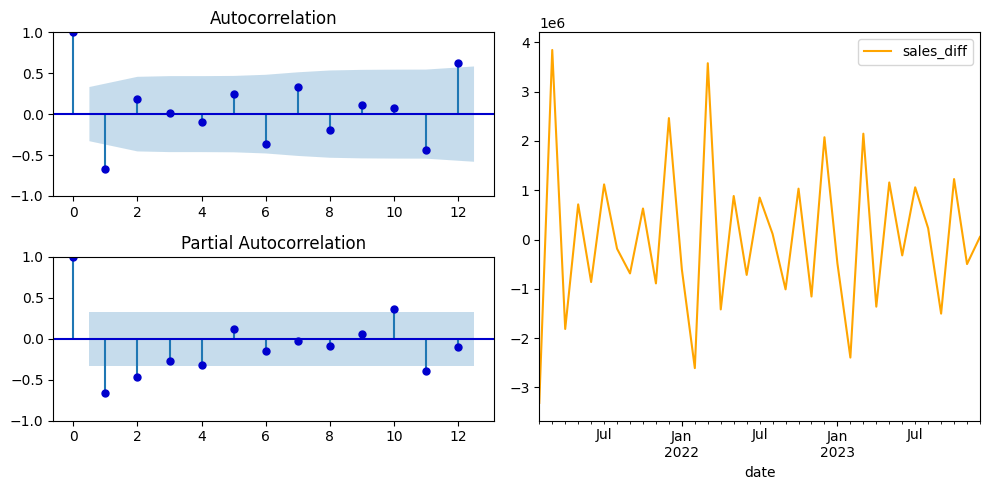

In [18]:
def plots_lag(data, lags=None):
    """Convert dataframe to datetime index"""
    dt_data = data.set_index('date').drop('sales', axis=1)
    dt_data.dropna(axis=0)
    
    
    law  = plt.subplot(122)
    acf  = plt.subplot(221)
    pacf = plt.subplot(223)
    
    dt_data.plot(ax=law, figsize=(10, 5), color='orange')
    # Plot the autocorrelation function:
    smt.graphics.plot_acf(dt_data, lags=lags, ax=acf, color='mediumblue')
    smt.graphics.plot_pacf(dt_data, lags=lags, ax=pacf, color='mediumblue')
    
    # Will also adjust spacing between subplots to minimize the overlaps:
    plt.tight_layout()

plots_lag(stationary_df, lags=12);

In [19]:
def built_supervised(data):
    supervised_df = data.copy()

    # Create column for each lag:
    for i in range(1, 13):
        col_name = 'lag_' + str(i)
        supervised_df[col_name] = supervised_df['sales_diff'].shift(i)

    # Drop null values:
    supervised_df = supervised_df.dropna().reset_index(drop=True)
    return supervised_df

In [20]:
model_df = built_supervised(stationary_df)
model_df 

,date,sales,sales_diff,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
0,2022-02-01,30224889.4,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14,-186460.03,1118771.98,-862202.76,713431.48,-1815377.86,3847267.36,-3315259.94
1,2022-03-01,33803330.01,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14,-186460.03,1118771.98,-862202.76,713431.48,-1815377.86,3847267.36
2,2022-04-01,32384738.78,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14,-186460.03,1118771.98,-862202.76,713431.48,-1815377.86
3,2022-05-01,33268156.57,883417.79,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14,-186460.03,1118771.98,-862202.76,713431.48
4,2022-06-01,32550527.99,-717628.58,883417.79,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14,-186460.03,1118771.98,-862202.76
5,2022-07-01,33401923.22,851395.23,-717628.58,883417.79,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14,-186460.03,1118771.98
6,2022-08-01,33515167.44,113244.22,851395.23,-717628.58,883417.79,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14,-186460.03
7,2022-09-01,32503656.55,-1011510.89,113244.22,851395.23,-717628.58,883417.79,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64,-687931.14
8,2022-10-01,33536594.33,1032937.78,-1011510.89,113244.22,851395.23,-717628.58,883417.79,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82,630060.64
9,2022-11-01,32379794.64,-1156799.69,1032937.78,-1011510.89,113244.22,851395.23,-717628.58,883417.79,-1418591.23,3578440.61,-2609950.8,-607464.26,2464888.47,-890312.82


In [21]:
model_df.info() # Supervised Dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        23 non-null     datetime64[ns]
 1   sales       23 non-null     Float64       
 2   sales_diff  23 non-null     Float64       
 3   lag_1       23 non-null     Float64       
 4   lag_2       23 non-null     Float64       
 5   lag_3       23 non-null     Float64       
 6   lag_4       23 non-null     Float64       
 7   lag_5       23 non-null     Float64       
 8   lag_6       23 non-null     Float64       
 9   lag_7       23 non-null     Float64       
 10  lag_8       23 non-null     Float64       
 11  lag_9       23 non-null     Float64       
 12  lag_10      23 non-null     Float64       
 13  lag_11      23 non-null     Float64       
 14  lag_12      23 non-null     Float64       
dtypes: Float64(14), datetime64[ns](1)
memory usage: 3.1 KB


In [22]:
def train_test_split(data):
    data = data.drop(['sales','date'], axis=1)
    train , test = data[:-12].values, data[-12:].values
    
    return train, test

train, test = train_test_split(model_df)
print(f"Shape of  Train: {train.shape}\nShape of  Test: {test.shape}")

Shape of  Train: (11, 13)
Shape of  Test: (12, 13)


In [23]:
def scale_data(train_set,test_set):
    """Scales data using MinMaxScaler and separates data into X_train, y_train,
    X_test, and y_test."""
    
    # Apply Min Max Scaler:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler = scaler.fit(train_set)
    
    # Reshape training set:
    train_set = train_set.reshape(train_set.shape[0],
                                  train_set.shape[1])
    train_set_scaled = scaler.transform(train_set)
    
    # Reshape test set:
    test_set = test_set.reshape(test_set.shape[0], 
                                test_set.shape[1])
    test_set_scaled = scaler.transform(test_set)
    
    X_train, y_train = train_set_scaled[:, 1:], train_set_scaled[:, 0:1].ravel() # returns the array, flattened!
    X_test, y_test = test_set_scaled[:, 1:], test_set_scaled[:, 0:1].ravel()
    
    return X_train, y_train, X_test, y_test, scaler


X_train, y_train, X_test, y_test, scaler_object = scale_data(train, test)
print(f"Shape of X Train: {X_train.shape}\nShape of y Train: {y_train.shape}\nShape of X Test: {X_test.shape}\nShape of y Test: {y_test.shape}")

Shape of X Train: (11, 12)
Shape of y Train: (11,)
Shape of X Test: (12, 12)
Shape of y Test: (12,)


In [24]:
def re_scaling(y_pred, x_test, scaler_obj, lstm=False):
    """For visualizing and comparing results, undoes the scaling effect on predictions."""
   # y_pred: model predictions
   # x_test: features from the test set used for predictions
   # scaler_obj: the scaler objects used for min-max scaling
   # lstm: indicate if the model run is the lstm. If True, additional transformation occurs 
    
    # Reshape y_pred:
    y_pred = y_pred.reshape(y_pred.shape[0],
                            1,
                            1)

    if not lstm:
        x_test = x_test.reshape(x_test.shape[0],
                                1, 
                                x_test.shape[1])

    # Rebuild test set for inverse transform:
    pred_test_set = []
    for index in range(0, len(y_pred)):
        pred_test_set.append(np.concatenate([y_pred[index], 
                                             x_test[index]],
                                             axis=1) )

    # Reshape pred_test_set:
    pred_test_set = np.array(pred_test_set)
    pred_test_set = pred_test_set.reshape(pred_test_set.shape[0],
                                          pred_test_set.shape[2])

    # Inverse transform:
    pred_test_set_inverted = scaler_obj.inverse_transform(pred_test_set)

    return pred_test_set_inverted

In [25]:
def prediction_df(unscale_predictions, origin_df):
    """Generates a dataframe that shows the predicted sales for each month
    for plotting results."""
    
    # unscale_predictions: the model predictions that do not have min-max or other scaling applied
    # origin_df: the original monthly sales dataframe
    
    # Create dataframe that shows the predicted sales:
    result_list = []
    sales_dates = list(origin_df[-13:].date)
    act_sales = list(origin_df[-13:].sales)

    for index in range(0, len(unscale_predictions)):
        result_dict = {}
        result_dict['pred_value'] = int(unscale_predictions[index][0] + act_sales[index])
        result_dict['date'] = sales_dates[index + 1]
        result_list.append(result_dict)

    df_result = pd.DataFrame(result_list)

    return df_result

In [26]:
model_scores = {}

def get_scores(unscale_df, origin_df, model_name):
    """Prints the root mean squared error, mean absolute error, and r2 scores
    for each model. Saves all results in a model_scores dictionary for
    comparison."""
    
    rmse = np.sqrt(mean_squared_error(origin_df.sales[-12:], 
                                      unscale_df.pred_value[-12:]))
    
    mae = mean_absolute_error(origin_df.sales[-12:], 
                              unscale_df.pred_value[-12:])
    
    r2 = r2_score(origin_df.sales[-12:], 
                  unscale_df.pred_value[-12:])
    
    model_scores[model_name] = [rmse, mae, r2]

    print(f"RMSE: {rmse}\nMAE: {mae}\nR2 Score: {r2}")

In [27]:

def plot_results(results, origin_df, model_name):
    """
    Plots the original sales data against the predicted sales data.

    Args:
        results (pd.DataFrame): DataFrame with 'date' and 'pred_value' columns 
                                 containing the unscaled predictions.
        origin_df (pd.DataFrame): DataFrame with 'date' and 'sales' columns 
                                  containing the original sales data.
        model_name (str): Name of the model used for forecasting, used in the plot title 
                            and filename.
    """
    fig, ax = plt.subplots(figsize=(15, 5))
    sns.lineplot(x=origin_df['date'], y=origin_df['sales'], data=origin_df, ax=ax,
                 label='Original', color='blue')
    sns.lineplot(x=results['date'], y=results['pred_value'], data=results, ax=ax,
                 label='Predicted', color='red')

    ax.set(xlabel="Date",
           ylabel="Sales",
           title=f"{model_name} Sales Forecasting Prediction")

    ax.legend(loc='best')


In [28]:
def regressive_model(train_data, test_data, model, model_name):
    """Runs regressive models in SKlearn framework. First calls scale_data
    to split into X and y and scale the data. Then fits and predicts. Finally,
    predictions are unscaled, scores are printed, and results are plotted and
    saved."""
    
    # Split into X & y and scale data:
    X_train, y_train, X_test, y_test, scaler_object = scale_data(train_data,
                                                                 test_data)

    # Run sklearn models:
    mod = model
    mod.fit(X_train, y_train)
    predictions = mod.predict(X_test) # y_pred=predictions

    # Undo scaling to compare predictions against original data:
    origin_df = m_df
    unscaled = re_scaling(predictions, X_test, scaler_object) # unscaled_predictions
    unscaled_df = prediction_df(unscaled, origin_df)

    # Print scores and plot results:
    get_scores(unscaled_df, origin_df, model_name)
    plot_results(unscaled_df, origin_df, model_name)

RMSE: 736590.7144007254
MAE: 488204.8591666666
R2 Score: 0.16456223223833077


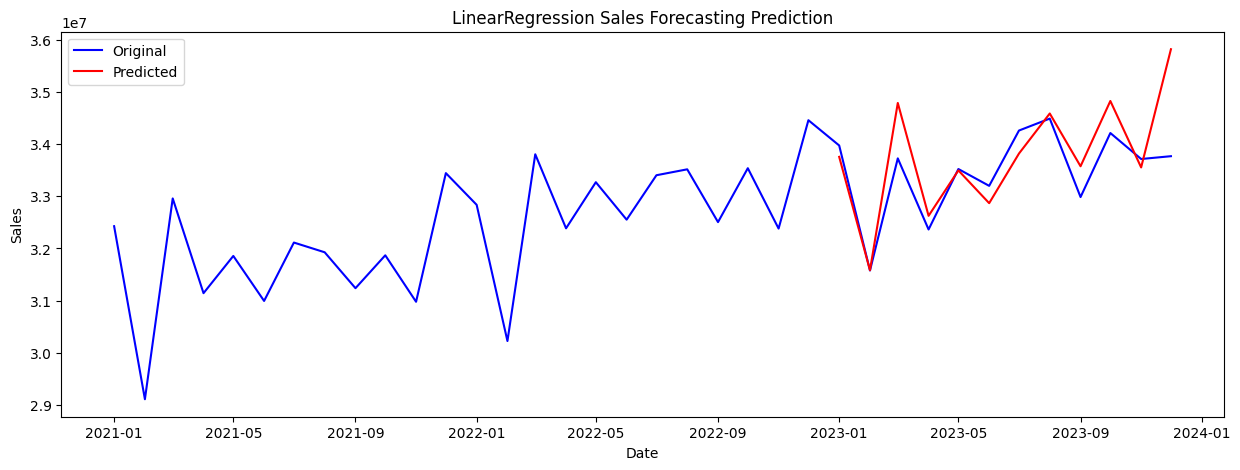

In [29]:
regressive_model(train, test, LinearRegression(), 'LinearRegression')

RMSE: 1113407.6110650885
MAE: 762495.5141666665
R2 Score: -0.9088420633310492


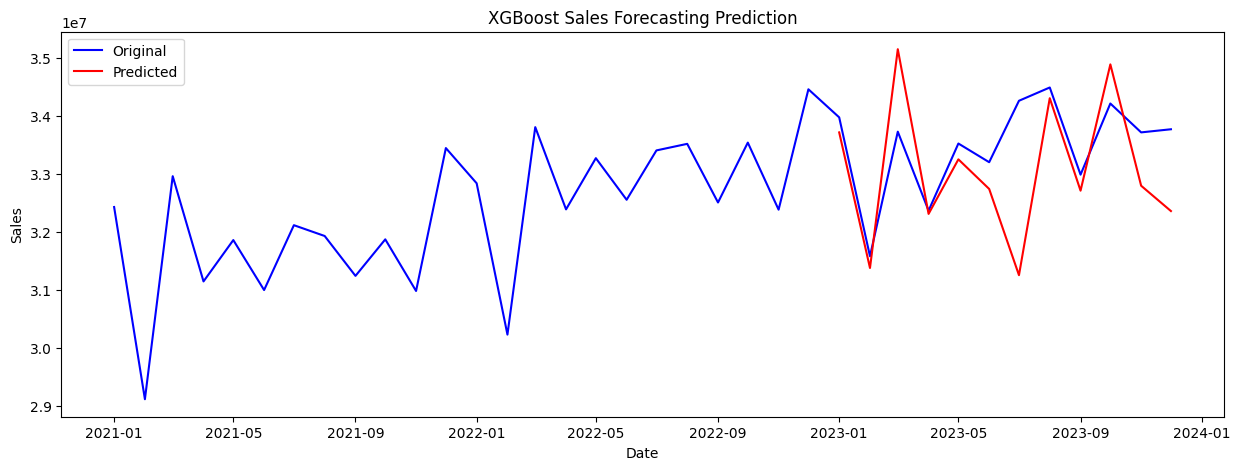

In [30]:
regressive_model(train, test, XGBRegressor(n_estimators=100,max_depth=3, 
                                           learning_rate=0.2,objective='reg:squarederror'), 'XGBoost')

In [31]:
datatime_df.index = pd.to_datetime(datatime_df.index)

In [32]:
datatime_df

,sales_diff
date,
2021-02-01,-3315259.94
2021-03-01,3847267.36
2021-04-01,-1815377.86
2021-05-01,713431.48
2021-06-01,-862202.76
2021-07-01,1118771.98
2021-08-01,-186460.03
2021-09-01,-687931.14
2021-10-01,630060.64


In [33]:
datatime_df

,sales_diff
date,
2021-02-01,-3315259.94
2021-03-01,3847267.36
2021-04-01,-1815377.86
2021-05-01,713431.48
2021-06-01,-862202.76
2021-07-01,1118771.98
2021-08-01,-186460.03
2021-09-01,-687931.14
2021-10-01,630060.64


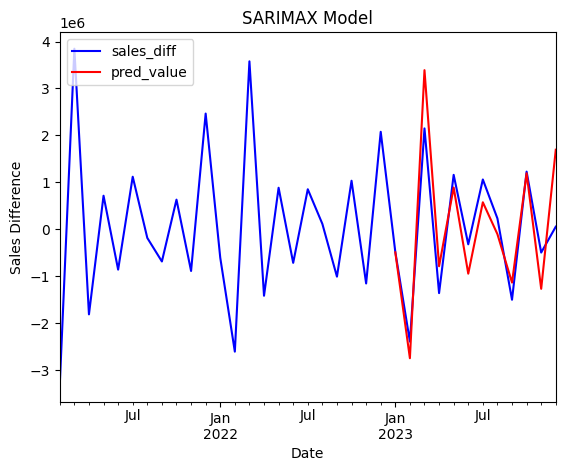

RMSE: 720695.8159800979
MAE: 559051.2637020359
R2 Score: 0.6727613807538926


In [39]:
def sarimax_model(data):
    # Model:
    order = (2, 0, 0) 
    seasonal_order = (1, 1, 0, 12)
    sar = sm.tsa.statespace.SARIMAX(data['sales_diff'], order=order,
                                     seasonal_order=seasonal_order,
                                     trend='c').fit(disp=False)

    # Generate predictions:
    n_predictions = 12
    start = len(data) - n_predictions
    end = len(data) - 1
    dynamic = len(data) - n_predictions
    
    data['pred_value'] = sar.predict(start=start, end=end, dynamic=dynamic)
    pred_df = data['pred_value'][start:]

    data[["sales_diff", "pred_value"]].plot(color=['blue', 'red'])
    plt.legend(loc='upper left')
    plt.title('SARIMAX Model')
    plt.xlabel('Date')
    plt.ylabel('Sales Difference')
    plt.show()

    rmse = np.sqrt(mean_squared_error(data['sales_diff'][-n_predictions:], data['pred_value'][-n_predictions:]))
    mae = mean_absolute_error(data['sales_diff'][-n_predictions:], data['pred_value'][-n_predictions:])
    r2 = r2_score(data['sales_diff'][-n_predictions:], data['pred_value'][-n_predictions:])
    model_scores['SARIMAX'] = [rmse, mae, r2]
    print(f"RMSE: {rmse}\nMAE: {mae}\nR2 Score: {r2}")

    return sar, data, pred_df

sar, datatime_df, predictions = sarimax_model(datatime_df.copy())

In [35]:
print(model_scores)

{'LinearRegression': [736590.7144007254, 488204.8591666666, 0.16456223223833077], 'XGBoost': [1113407.6110650885, 762495.5141666665, -0.9088420633310492], 'SARIMAX': [720695.8159800979, 559051.2637020359, 0.6727613807538926]}


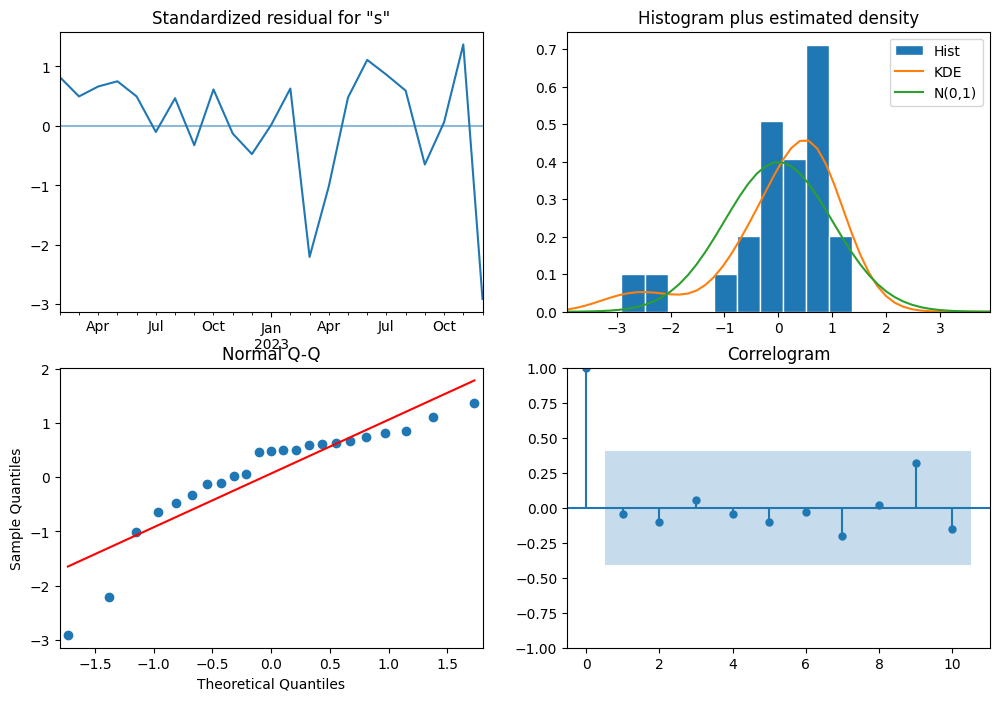

In [36]:
sar.plot_diagnostics(figsize=(12, 8));

,index,RMSE,MAE,R2
0,XGBoost,1.113408e+06,762495.514167,-0.908842
1,LinearRegression,7.365907e+05,488204.859167,0.164562
2,SARIMAX,7.206958e+05,559051.263702,0.672761


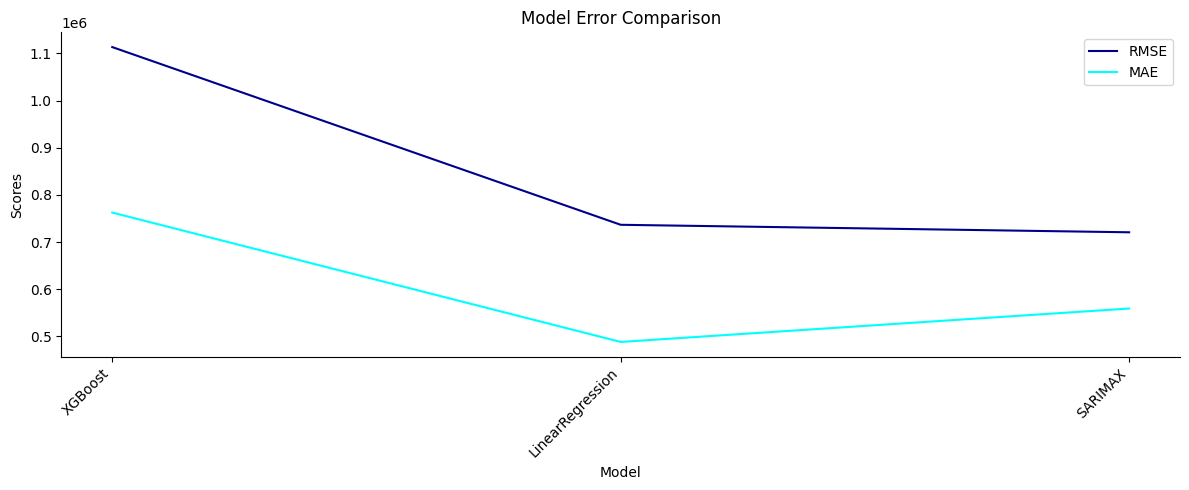

In [37]:
import pickle
pickle.dump(model_scores, open("ARIMAmodel_scores.p", "wb"))

def create_results_df():
    with open("ARIMAmodel_scores.p", "rb") as f:
        results_dict = pickle.load(f)

    results_df = pd.DataFrame.from_dict(results_dict, orient='index',
                                         columns=['RMSE', 'MAE','R2'])
    results_df = results_df.sort_values(by='RMSE', ascending=False).reset_index()
    results_df.to_csv('./results.csv')
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(x=np.arange(len(results_df)), y='RMSE', data=results_df, ax=ax,
                 label='RMSE', color='darkblue')
    sns.lineplot(x=np.arange(len(results_df)), y='MAE', data=results_df, ax=ax,
                 label='MAE', color='cyan')
    plt.xticks(np.arange(len(results_df)), results_df['index'], rotation=45, ha='right')
    ax.set(xlabel="Model",
           ylabel="Scores",
           title="Model Error Comparison")
    sns.despine()
    plt.tight_layout()
    return results_df

results = create_results_df()
results